In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('regression_final.csv')
print(df.shape)
print(df.describe())
print(df.isnull().sum())

(78, 11)
         WPI_yoy    IIP_yoy  ExchangeRate_yoy  Imports_yoy  \
count  78.000000  78.000000         78.000000    78.000000   
mean    4.484838   4.356564          3.655973    11.207111   
std     5.375979   8.370383          3.795641    28.491719   
min    -4.182754 -13.200934         -4.303210   -34.856210   
25%     0.644301   1.320497          1.228504    -7.030332   
50%     2.512692   3.734661          2.705245     5.361948   
75%     7.448741   5.645139          6.427541    18.540407   
max    16.629044  51.965357         14.232607   114.000306   

       MarketBorrowing_yoy  COVID_Dummy  Repo_Rate   brent_yoy  \
count            78.000000    78.000000  78.000000   78.000000   
mean             14.641851     0.166667   5.467308    6.790061   
std              50.582410     0.375090   1.085824   37.464108   
min             -85.135211     0.000000   4.000000  -49.951355   
25%             -14.952477     0.000000   4.000000  -16.130873   
50%              12.393414     0.000

In [ ]:
# Plot each variable over time (line plots)
# Plot correlation heatmap
# Plot boxplots for all IVs
# Plot distribution of DV (Inflation_Rate_YoY)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

IVs = ['WPI_yoy','IIP_yoy','Imports_yoy','MarketBorrowing_yoy',
       'COVID_Dummy','Repo_Rate','brent_yoy','CPI_food_lag1_yoy']

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X = df[IVs]
X = sm.add_constant(X) # adding a constant column

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

               feature         VIF
0                const  195.675889
1              WPI_yoy    8.728555
2              IIP_yoy    2.699777
3          Imports_yoy    6.883182
4  MarketBorrowing_yoy    1.548236
5          COVID_Dummy    3.499948
6            Repo_Rate    5.377900
7            brent_yoy    6.003939
8    CPI_food_lag1_yoy    1.531436


In [ ]:
import statsmodels.api as sm

X = sm.add_constant(df[IVs])
model = sm.OLS(df['Inflation_Rate_YoY'], X).fit(
    cov_type='HAC', cov_kwds={'maxlags': 3}
)
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Inflation_Rate_YoY   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     38.28
Date:                Thu, 23 Apr 2026   Prob (F-statistic):           1.90e-22
Time:                        19:45:42   Log-Likelihood:                -92.181
No. Observations:                  78   AIC:                             202.4
Df Residuals:                      69   BIC:                             223.6
Df Model:                           8                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   2.9656    

In [ ]:
print(f"Durbin-Watson test statistic: {dw:.3f}")

print(f"Breusch-Pagan test: \n\tLagrange Multiplier Statistic: {bp[0]:.3f}\n\tP-value: {bp[1]:.3f}\n\tF-Statistic: {bp[2]:.3f}\n\tF-Statistic P-value: {bp[3]:.3f}")

print(f"Jarque-Bera test: \n\tStatistic: {jb[0]:.3f}\n\tP-value: {jb[1]:.3f}")

print(f"Shapiro-Wilk test: \n\tStatistic: {sw[0]:.3f}\n\tP-value: {sw[1]:.3f}")

print("Ljung-Box test for serial correlation:")
print(lb)

Durbin-Watson test statistic: 1.003
Breusch-Pagan test: 
	Lagrange Multiplier Statistic: 5.367
	P-value: 0.718
	F-Statistic: 0.637
	F-Statistic P-value: 0.744
Jarque-Bera test: 
	Statistic: 27.041
	P-value: 0.000
Shapiro-Wilk test: 
	Statistic: 0.949
	P-value: 0.004
Ljung-Box test for serial correlation:
      lb_stat  lb_pvalue
6   21.819570   0.001305
12  27.213171   0.007199


In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from scipy import stats

dw  = durbin_watson(model.resid)
bp  = het_breuschpagan(model.resid, X)
jb  = stats.jarque_bera(model.resid)
sw  = stats.shapiro(model.resid)
lb  = acorr_ljungbox(model.resid, lags=[6,12], return_df=True)

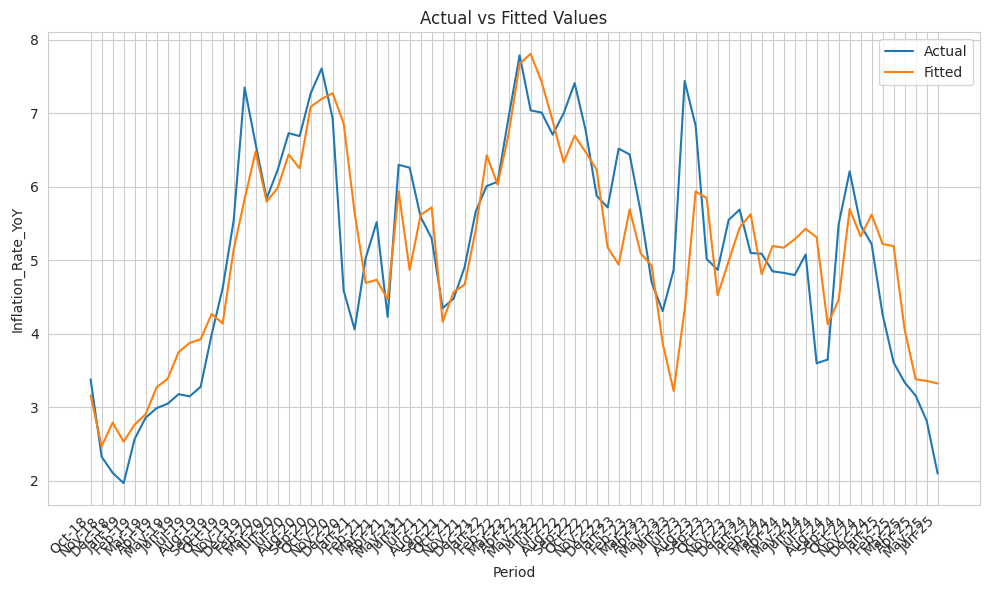

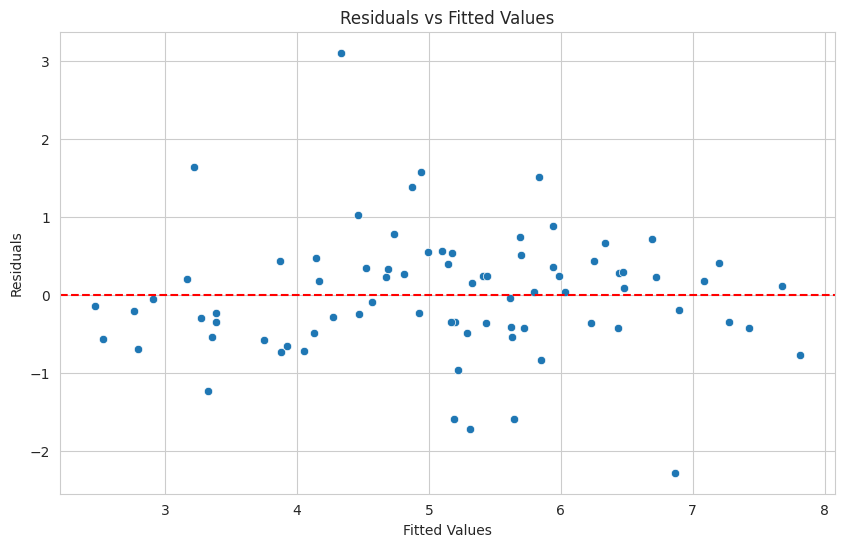

<Figure size 1000x600 with 0 Axes>

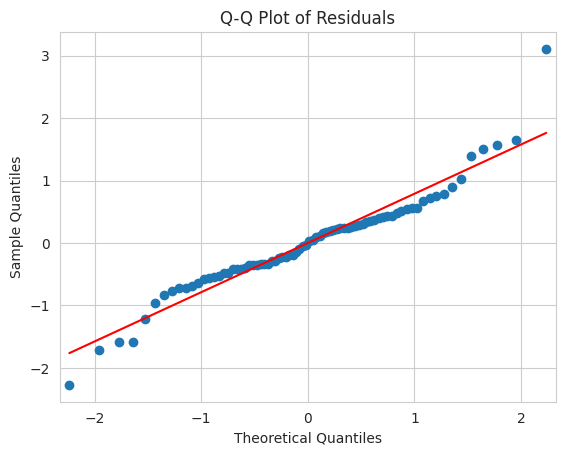

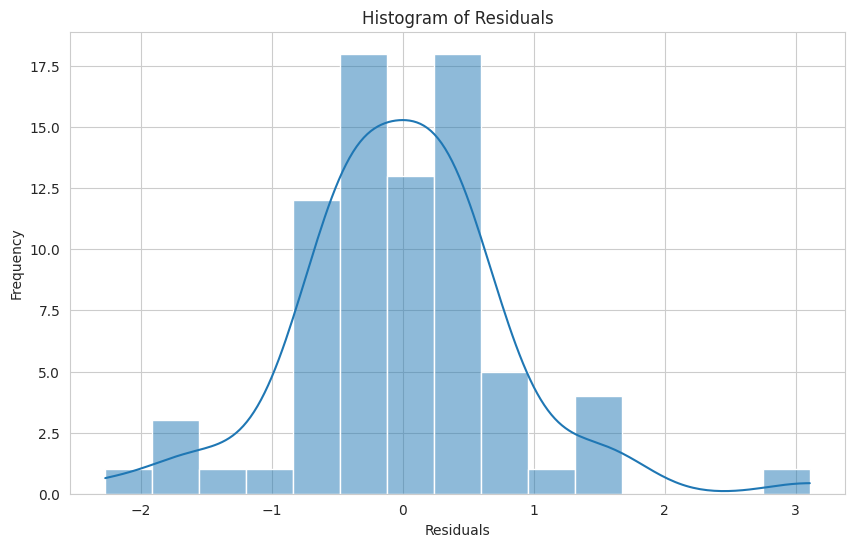

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set style for plots
sns.set_style("whitegrid")

# 1. Actual vs Fitted line chart
plt.figure(figsize=(10, 6))
plt.plot(df['Period'], df['Inflation_Rate_YoY'], label='Actual')
plt.plot(df['Period'], model.fittedvalues, label='Fitted')
plt.title('Actual vs Fitted Values')
plt.xlabel('Period')
plt.ylabel('Inflation_Rate_YoY')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Residuals vs Fitted scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# 3. Q-Q plot of residuals
plt.figure(figsize=(10, 6))
sm.qqplot(model.resid, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# 4. Residual histogram
plt.figure(figsize=(10, 6))
sns.histplot(model.resid, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define independent and dependent variables
X_model = df[IVs]
y_model = df['Inflation_Rate_YoY']

tscv = TimeSeriesSplit(n_splits=5)

# Initialize models
models = {
    'OLS Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest Regression': RandomForestRegressor(random_state=42) # Added random_state for reproducibility
}

# Prepare StandardScaler
scaler = StandardScaler()

print("Cross-Validation R² Scores (Mean ± Std):")
for name, model in models.items():
    # Scale X for Ridge and Lasso, and also for RandomForest to be consistent (though less critical)
    X_scaled = scaler.fit_transform(X_model)

    # Perform cross-validation
    scores = cross_val_score(model, X_scaled, y_model, cv=tscv, scoring='r2')

    print(f"{name}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Cross-Validation R² Scores (Mean ± Std):
OLS Regression: -3.7291 ± 6.3939
Ridge Regression: -1.1279 ± 1.6804
Lasso Regression: -2.9098 ± 3.0885
Random Forest Regression: -2.0650 ± 1.7309


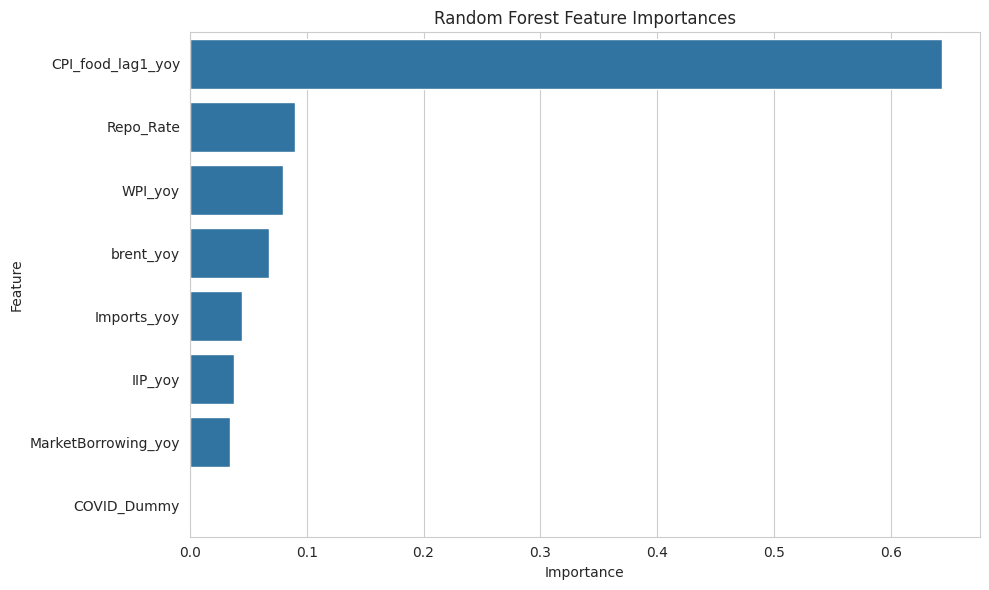

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# Initialize and fit the RandomForestRegressor
rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_scaled, y_model)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': IVs,
    'importance': rf.feature_importances_
})

# Sort by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Plot feature importances as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
### Regression Results Summary

| Variable            | Coefficient | p-value | Significance | Economic Meaning |
| :------------------ | :---------- | :------ | :----------- | :--------------- |
| **Intercept**       | 2.9656      | 0.059   |              |                  |
| **WPI_yoy**         | 0.2170      | 0.000   | ***          |                  |
| **IIP_yoy**         | 0.0459      | 0.012   | **           |                  |
| **Imports_yoy**     | -0.0244     | 0.001   | ***          |                  |
| **MarketBorrowing_yoy** | 0.0044      | 0.040   | *            |                  |
| **COVID_Dummy**     | -0.3081     | 0.562   |              |                  |
| **Repo_Rate**       | -0.0785     | 0.739   |              |                  |
| **brent_yoy**       | -0.0023     | 0.617   |              |                  |
| **CPI_food_lag1_yoy** | 0.2871      | 0.000   | ***          |                  |

---
*Significance codes: *** p < 0.001, ** p < 0.01, * p < 0.05*


In [6]:
import pandas as pd

df = pd.read_csv('regression_final.csv')
df['Period'] = pd.to_datetime(df['Period'], format='%b-%y')
df = df.sort_values('Period').reset_index(drop=True)
df['inflation_lag1'] = df['Inflation_Rate_YoY'].shift(1)
df = df.dropna().reset_index(drop=True)

In [7]:
IVs = [
    'WPI_yoy',
    'IIP_yoy',
    'Imports_yoy',
    'MarketBorrowing_yoy',
    'CPI_food_lag1_yoy',
    'inflation_lag1'   # 🔥 NEW VARIABLE
]

In [8]:
import statsmodels.api as sm

X = df[IVs]
y = df['Inflation_Rate_YoY']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':3})

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Inflation_Rate_YoY   R-squared:                       0.773
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     76.74
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           8.33e-29
Time:                        01:11:19   Log-Likelihood:                -83.360
No. Observations:                  77   AIC:                             180.7
Df Residuals:                      70   BIC:                             197.1
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   1.1619    

In [10]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

dw = durbin_watson(model.resid)
lb = acorr_ljungbox(model.resid, lags=[6,12], return_df=True)

print("Durbin-Watson:", dw)
print(lb)

Durbin-Watson: 1.3198467561660223
      lb_stat  lb_pvalue
6   17.047787   0.009109
12  29.381616   0.003457


In [11]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from scipy import stats

# Recalculate tests based on the new model
dw  = durbin_watson(model.resid)
bp  = het_breuschpagan(model.resid, X)
jb  = stats.jarque_bera(model.resid)
sw  = stats.shapiro(model.resid)
lb  = acorr_ljungbox(model.resid, lags=[6,12], return_df=True)

print(f"Durbin-Watson test statistic: {dw:.3f}")

print(f"Breusch-Pagan test: \n\tLagrange Multiplier Statistic: {bp[0]:.3f}\n\tP-value: {bp[1]:.3f}\n\tF-Statistic: {bp[2]:.3f}\n\tF-Statistic P-value: {bp[3]:.3f}")

print(f"Jarque-Bera test: \n\tStatistic: {jb[0]:.3f}\n\tP-value: {jb[1]:.3f}")

print(f"Shapiro-Wilk test: \n\tStatistic: {sw[0]:.3f}\n\tP-value: {sw[1]:.3f}")

print("Ljung-Box test for serial correlation:")
print(lb)

Durbin-Watson test statistic: 1.320
Breusch-Pagan test: 
	Lagrange Multiplier Statistic: 5.741
	P-value: 0.453
	F-Statistic: 0.940
	F-Statistic P-value: 0.472
Jarque-Bera test: 
	Statistic: 26.603
	P-value: 0.000
Shapiro-Wilk test: 
	Statistic: 0.955
	P-value: 0.008
Ljung-Box test for serial correlation:
      lb_stat  lb_pvalue
6   17.047787   0.009109
12  29.381616   0.003457


In [12]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from scipy import stats

dw  = durbin_watson(model.resid)
bp  = het_breuschpagan(model.resid, X)
jb  = stats.jarque_bera(model.resid)
sw  = stats.shapiro(model.resid)
lb  = acorr_ljungbox(model.resid, lags=[6,12], return_df=True)

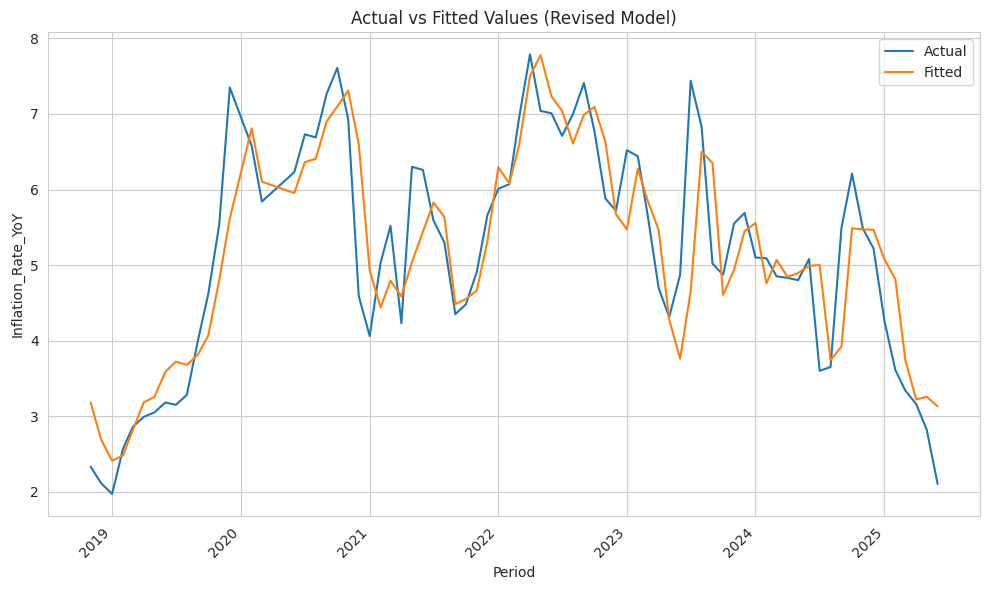

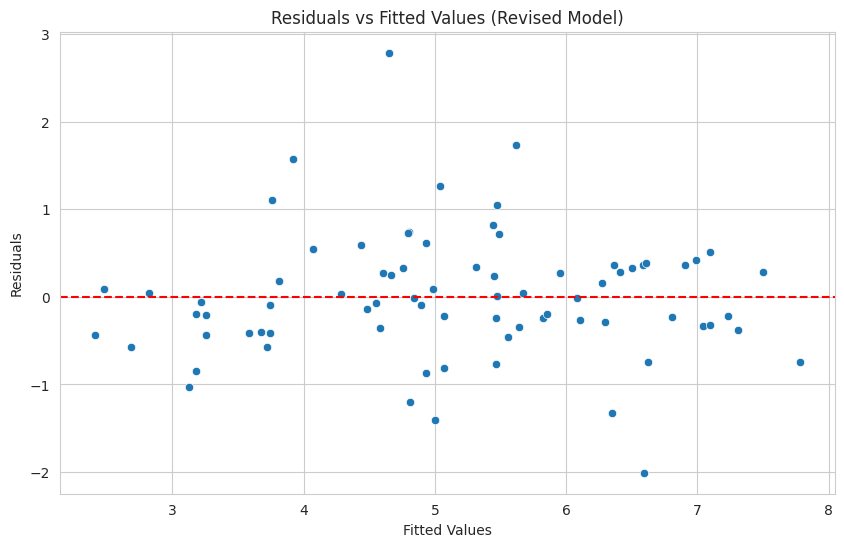

<Figure size 1000x600 with 0 Axes>

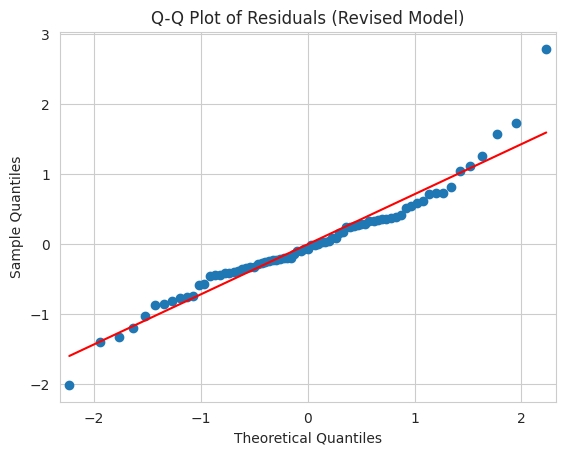

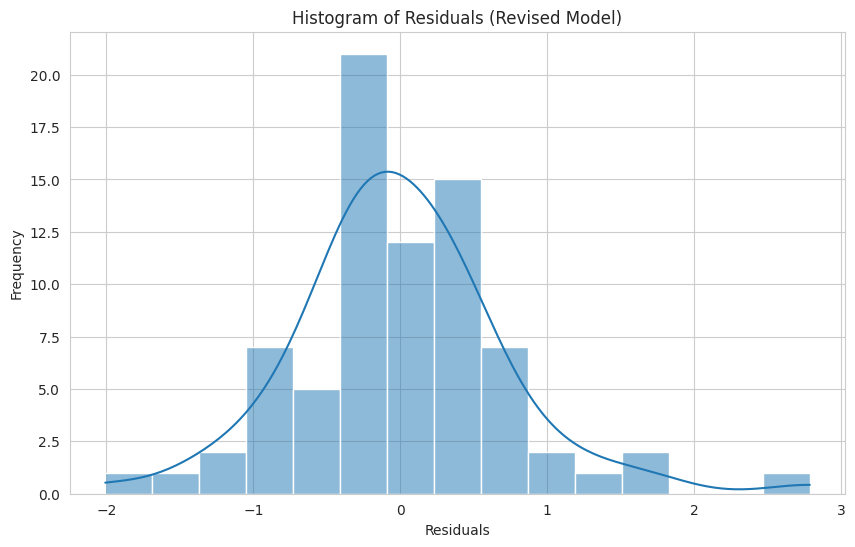

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Set style for plots
sns.set_style("whitegrid")

# 1. Actual vs Fitted line chart
plt.figure(figsize=(10, 6))
plt.plot(df['Period'], df['Inflation_Rate_YoY'], label='Actual')
plt.plot(df['Period'], model.fittedvalues, label='Fitted')
plt.title('Actual vs Fitted Values (Revised Model)')
plt.xlabel('Period')
plt.ylabel('Inflation_Rate_YoY')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Residuals vs Fitted scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Fitted Values (Revised Model)')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()

# 3. Q-Q plot of residuals
plt.figure(figsize=(10, 6))
sm.qqplot(model.resid, line='s')
plt.title('Q-Q Plot of Residuals (Revised Model)')
plt.show()

# 4. Residual histogram
plt.figure(figsize=(10, 6))
sns.histplot(model.resid, kde=True)
plt.title('Histogram of Residuals (Revised Model)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np

# Define independent and dependent variables using the current IVs
X_model = df[IVs]
y_model = df['Inflation_Rate_YoY']

tscv = TimeSeriesSplit(n_splits=5)

# Initialize models
models = {
    'OLS Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Random Forest Regression': RandomForestRegressor(random_state=42)
}

# Prepare StandardScaler
scaler = StandardScaler()

print("Cross-Validation R² Scores (Mean ± Std) with updated IVs:")
for name, model in models.items():
    # Scale X for all models
    X_scaled = scaler.fit_transform(X_model)

    # Perform cross-validation
    scores = cross_val_score(model, X_scaled, y_model, cv=tscv, scoring='r2')

    print(f"{name}: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

Cross-Validation R² Scores (Mean ± Std) with updated IVs:
OLS Regression: -0.8352 ± 1.3223
Ridge Regression: 0.1589 ± 0.3660
Lasso Regression: -0.3700 ± 0.4459
Random Forest Regression: 0.2173 ± 0.3257


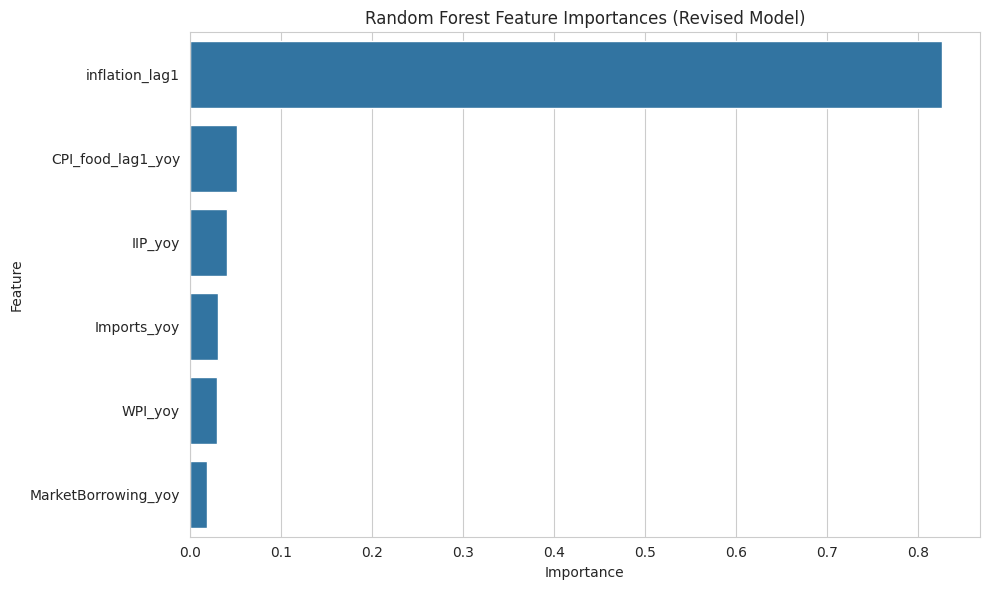

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

rf = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42)
rf.fit(X_scaled, y_model)

# Get feature importances
feature_importances = pd.DataFrame({
    'feature': IVs, # Using the IVs list that was used to create X_model
    'importance': rf.feature_importances_
})

# Sort by importance
feature_importances = feature_importances.sort_values(by='importance', ascending=False)

# Plot feature importances as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances)
plt.title('Random Forest Feature Importances (Revised Model)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [19]:
df.to_csv('regression_final.csv', index=False)

In [20]:
import pandas as pd

# Reload the CSV to check its current state after the save operation
reloaded_df_after_save = pd.read_csv('regression_final.csv')

# Display the columns of the reloaded DataFrame
print('Columns in regression_final.csv after re-saving:')
print(reloaded_df_after_save.columns)

# Check if 'inflation_lag1' is now present
if 'inflation_lag1' in reloaded_df_after_save.columns:
    print("\n'inflation_lag1' column is now successfully present in the CSV.")
else:
    print("\n'inflation_lag1' column is still missing from the CSV. Further investigation is needed.")

Columns in regression_final.csv after re-saving:
Index(['Period', 'WPI_yoy', 'IIP_yoy', 'ExchangeRate_yoy', 'Imports_yoy',
       'MarketBorrowing_yoy', 'COVID_Dummy', 'Repo_Rate', 'brent_yoy',
       'CPI_food_lag1_yoy', 'Inflation_Rate_YoY', 'inflation_lag1'],
      dtype='object')

'inflation_lag1' column is now successfully present in the CSV.


In [16]:
# The 'regression_final.csv' file has been updated with the 'inflation_lag1' column in cell v9x2a1MOCzdF.
# The file is now saved.

In [18]:
import pandas as pd

# Reload the CSV to check its current state
reloaded_df = pd.read_csv('regression_final.csv')

# Display the columns of the reloaded DataFrame
print('Columns in reloaded regression_final.csv:')
print(reloaded_df.columns)

Columns in reloaded regression_final.csv:
Index(['Period', 'WPI_yoy', 'IIP_yoy', 'ExchangeRate_yoy', 'Imports_yoy',
       'MarketBorrowing_yoy', 'COVID_Dummy', 'Repo_Rate', 'brent_yoy',
       'CPI_food_lag1_yoy', 'Inflation_Rate_YoY'],
      dtype='object')
